# Exercises - GEO4902-01 - General modeling concepts

[Save google-collab as jupyter notebook, with your name in the filename, and upload on canvas]

# Exercise 01A - How to access the latest weather forecast:

In [1]:
# import python packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy as cy
from matplotlib.dates import DateFormatter

##### Specify the file on the thredds server. For example the full file of latest forecast of the AROME Arctic weather model. Note, at this point only metadata is retrieved

In [2]:
url='https://thredds.met.no/thredds/dodsC/aromearcticlatest/latest/arome_arctic_lagged_6_h_latest_2_5km_latest.nc'
dataset = xr.open_dataset(url)

### Metadata

In [3]:
dataset

<xarray.Dataset> Size: 17GB
Dimensions:                    (time: 62, pressure: 2, ensemble_member: 6,
                                y: 949, x: 739, height0: 1, height2: 1,
                                height1: 1, height_above_msl: 1)
Coordinates:
  * time                       (time) datetime64[ns] 496B 2026-09-14T15:00:00...
  * pressure                   (pressure) float32 8B 850.0 925.0
  * ensemble_member            (ensemble_member) int16 12B 0 1 2 3 4 5
  * y                          (y) float32 4kB -8.98e+05 ... 1.472e+06
  * x                          (x) float32 3kB 2.786e+05 2.811e+05 ... 2.124e+06
    longitude                  (y, x) float64 6MB ...
    latitude                   (y, x) float64 6MB ...
  * height0                    (height0) float32 4B 2.0
  * height2                    (height2) float32 4B 10.0
  * height1                    (height1) float32 4B 0.0
  * height_above_msl           (height_above_msl) float32 4B 0.0
Data variables: (12/15)
    forecast_reference_time    datetime64[ns] 8B ...
    projection_lambert         int32 4B ...
    x_wind_pl                  (time, pressure, ensemble_member, y, x) float32 2GB ...
    y_wind_pl                  (time, pressure, ensemble_member, y, x) float32 2GB ...
    air_temperature_pl         (time, pressure, ensemble_member, y, x) float32 2GB ...
    air_temperature_2m         (time, height0, ensemble_member, y, x) float32 1GB ...
    ...                         ...
    cloud_area_fraction        (time, height1, ensemble_member, y, x) float32 1GB ...
    air_pressure_at_sea_level  (time, height_above_msl, ensemble_member, y, x) float32 1GB ...
    precipitation_amount_acc   (time, height1, ensemble_member, y, x) float32 1GB ...
    snowfall_amount_acc        (time, height1, ensemble_member, y, x) float32 1GB ...
    wind_speed_of_gust         (time, height2, ensemble_member, y, x) float32 1GB ...
    fog_area_fraction          (time, height1, ensemble_member, y, x) float32 1GB ...
Attributes: (12/23)
    Conventions:                     CF-1.6, ACDD
    institution:                     Norwegian Meteorological Institute, MET ...
    institution_short_name:          NO/MET
    creator_url:                     met.no
    source:                          AROME-Arctic 2.5km
    title:                           AROME_Arctic 2.5km
    ...                              ...
    dataset_production_status:       Active
    iso_topic_category:              climatologyMeteorologyAtmosphere
    spatial_representation:          grid
    naming_authority:                no.met
    history:                         2026-09-14T17:18:51 creation by fimex
    DODS_EXTRA.Unlimited_Dimension:  time

### Find a specific point and plot the forecast. 
###### Note AROME Arctic is on an irregular grid, so the xarray.sel functionality does not work:

In [4]:
#Find a specific location, for example for Longyearbyen
lat = 78.24
lon = 15.46
dataset = dataset.set_xindex(("latitude", "longitude"), xr.indexes.NDPointIndex)
t2m_point = dataset["air_temperature_2m"].sel(latitude = lat, longitude = lon, method='nearest').squeeze()


In [5]:
t2m_point

<xarray.DataArray 'air_temperature_2m' (time: 62, ensemble_member: 6)> Size: 1kB
[372 values with dtype=float32]
Coordinates:
  * time             (time) datetime64[ns] 496B 2026-09-14T15:00:00 ... 2026-...
  * ensemble_member  (ensemble_member) int16 12B 0 1 2 3 4 5
    height0          float32 4B 2.0
    x                float32 4B 8.461e+05
    y                float32 4B 3.87e+05
    latitude         float64 8B 78.25
    longitude        float64 8B 15.49
Attributes:
    long_name:      Screen level temperature (T2M)
    standard_name:  air_temperature
    units:          K
    grid_mapping:   projection_lambert
    _ChunkSizes:    [  1   1   3 475 370]

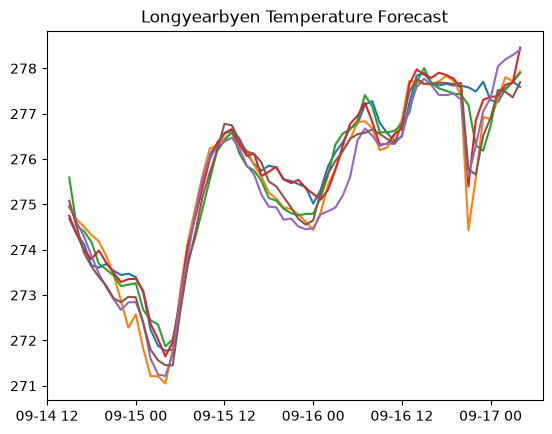

In [6]:
from matplotlib import pyplot as plt

plt.plot(dataset.time, t2m_point, '-')

plt.title("Longyearbyen Temperature Forecast")
plt.show()

### Plot one forecast on a map

#### Choose ensemble member and timestep 

In [7]:
t2m_area = dataset["air_temperature_2m"].sel(ensemble_member=1).isel(time=0).squeeze()

Text(0.5, 0.98, 'Temperature forecast')

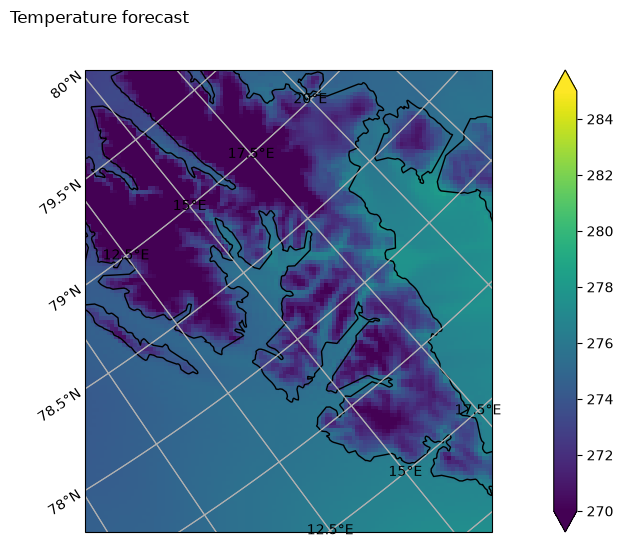

In [13]:
%matplotlib inline
projection = cy.crs.LambertConformal(central_longitude =dataset.projection_lambert.longitude_of_central_meridian,
                                       central_latitude  =dataset.projection_lambert.latitude_of_projection_origin,
                                       standard_parallels = dataset.projection_lambert.standard_parallel)
fig = plt.figure(figsize=[16, 6])

ax = fig.add_subplot(projection=projection)
ax.set_extent([lon - 1.5, lon + 1.5, lat-1.5, lat+1.5], cy.crs.PlateCarree())

ax.gridlines()
ax.add_feature(cy.feature.COASTLINE, zorder=2) 
cf = ax.pcolormesh(t2m_area.longitude,t2m_area.latitude,t2m_area[:,:],transform=cy.crs.PlateCarree(), zorder=1)
cf.set_clim(270,285)
gl = ax.gridlines(draw_labels=True)
gl.top_labels   = False
gl.right_labels = False

#cbaxes = fig.add_axes([0.92, 0.025, 0.025, 0.9])
cbar = fig.colorbar(cf, ax=ax, orientation='vertical', extend='both')
#plt.show()
fig.suptitle('Temperature forecast')
